In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
import scipy
from scipy.linalg import sqrtm

In [2]:
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
        
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    #if max_err > check_tol:
    #    mag = np.abs(eigvals)
    #    print("Sorted |eigvals|:", np.sort(mag))
    #    raise RuntimeError(
    #        fr"Self-consistency violated: max |Δ| = {max_err}"
    #    )
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q1,H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E,ets=1e-6j):
    d = H_q1.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E+ets)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E+ets)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i < N//2:
            H_qi = H_q1
        elif i >=N//2:
            H_qi = H_q2

        # 左端点
        if i == 0:
            A_DD[i][i] = EI_gai - H_qi - Sigma_L

        # 右端点
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_qi - Sigma_R

        # 中间
        else:
            A_DD[i][i] = EI_gai - H_qi

        # hopping
        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD = np.block(A_DD)
    G_DD = np.linalg.inv(A_DD)
    return G_DD , A_DD , Sigma_R , Sigma_L 

def gamma_feilei_old(which, side,E):

    G_DD , A_DD , Sigma_R , Sigma_L = Gr_DD(
        H_q1,H_q2, H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E, ets=1e-6j
    )

    # step 1: Γ
    Gamma_L = 1j * (Sigma_L - Sigma_L.conj().T)
    Gamma_R = 1j * (Sigma_R - Sigma_R.conj().T)

    # step 2: Nambu 
    P_e = np.diag([1,1,0,0])
    P_h = np.diag([0,0,1,1])

    if side == 'L':
        Gamma = Gamma_L
    elif side == 'R':
        Gamma = Gamma_R
    else:
        raise ValueError("side must be 'L' or 'R'")

    if which == 'e':
        return P_e @ Gamma @ P_e
    elif which == 'h':
        return P_h @ Gamma @ P_h
    else:
        raise ValueError("which must be 'e' or 'h'")

def gamma_feilei(which, side, E):
    G_DD , A_DD , Sigma_R , Sigma_L = Gr_DD(
        H_q1,H_q2, H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E, ets=1e-6j
    )

    Gamma_L = 1j * (Sigma_L - Sigma_L.conj().T)
    Gamma_R = 1j * (Sigma_R - Sigma_R.conj().T)

    if side == 'L':
        Gamma = Gamma_L
    elif side == 'R':
        Gamma = Gamma_R
    else:
        raise ValueError("side must be 'L' or 'R'")

    dim = Gamma.shape[0] // 2

    Gamma_ee = Gamma[:dim, :dim]
    Gamma_hh = Gamma[dim:, dim:]

    if which == 'e':
        return Gamma_ee
    elif which == 'h':
        return Gamma_hh
    else:
        raise ValueError("which must be 'e' or 'h'")

def G_feilei_old(which1, which2, side1, side2,E):

    G_DD , A_DD , Sigma_R , Sigma_L = Gr_DD(
        H_q1,H_q2, H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E, ets=1e-6j
    )

    dim = 4  

    idx_L = np.arange(0, dim)
    idx_R = np.arange(dim*(N-1), dim*N)

    if side1 == 'L':
        idx_row = idx_L
    elif side1 == 'R':
        idx_row = idx_R
    else:
        raise ValueError("side1 must be L or R")

    if side2 == 'L':
        idx_col = idx_L
    elif side2 == 'R':
        idx_col = idx_R
    else:
        raise ValueError("side2 must be L or R")

    G_qp = G_DD[np.ix_(idx_row, idx_col)]

    P_e = np.diag([1,1,0,0])
    P_h = np.diag([0,0,1,1])

    if which1 == 'e':
        P_out = P_e
    elif which1 == 'h':
        P_out = P_h
    else:
        raise ValueError("which1 must be e or h")

    if which2 == 'e':
        P_in = P_e
    elif which2 == 'h':
        P_in = P_h
    else:
        raise ValueError("which2 must be e or h")

    return P_out @ G_qp @ P_in

def G_feilei(which1, which2, side1, side2, E):

    G_DD , A_DD , Sigma_R , Sigma_L = Gr_DD(
        H_q1,H_q2, H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E, ets=1e-6j
    )

    dim = 4  

    idx_L = np.arange(0, dim)
    idx_R = np.arange(dim*(N-1), dim*N)

    if side1 == 'L':
        idx_row = idx_L
    elif side1 == 'R':
        idx_row = idx_R
    else:
        raise ValueError("side1 must be L or R")

    if side2 == 'L':
        idx_col = idx_L
    elif side2 == 'R':
        idx_col = idx_R
    else:
        raise ValueError("side2 must be L or R")

    G_qp = G_DD[np.ix_(idx_row, idx_col)]

    subdim = dim // 2  # =2

    if which1 == 'e' and which2 == 'e':
        return G_qp[:subdim, :subdim]        # G^{ee}

    elif which1 == 'e' and which2 == 'h':
        return G_qp[:subdim, subdim:]        # G^{eh}

    elif which1 == 'h' and which2 == 'e':
        return G_qp[subdim:, :subdim]        # G^{he}

    elif which1 == 'h' and which2 == 'h':
        return G_qp[subdim:, subdim:]        # G^{hh}

    else:
        raise ValueError("which must be e or h")

def sanshejuzhen_old(which1, which2, side1, side2,E):

    Gamma_q = gamma_feilei(which1, side1,E)  # Γ_q^α
    Gamma_p = gamma_feilei(which2, side2,E)  # Γ_p^β

    G_qp = G_feilei(which1, which2, side1, side2,E)


    def sqrtm_hermitian(M):
        w, v = np.linalg.eigh(M)
        w = np.clip(w, 0, None)  
        return v @ np.diag(np.sqrt(w)) @ v.conj().T

    sqrt_Gamma_q = sqrtm_hermitian(Gamma_q)
    sqrt_Gamma_p = sqrtm_hermitian(Gamma_p)

    S = 1j * sqrt_Gamma_q @ G_qp @ sqrt_Gamma_p


    if side1 == side2 and which1 == which2:
        I_2 = np.eye(2) 
        S = S - I_2
    return S

def sanshejuzhen(which1, which2, side1, side2,E):

    Gamma_q = gamma_feilei(which1, side1,E)  # Γ_q^α
    Gamma_p = gamma_feilei(which2, side2,E)  # Γ_p^β

    G_qp = G_feilei(which1, which2, side1, side2,E)

    sqrt_Gamma_q = np.sqrt(Gamma_q)
    sqrt_Gamma_p = np.sqrt(Gamma_p)

    S = 1j * sqrt_Gamma_q @ G_qp @ sqrt_Gamma_p


    if side1 == side2 and which1 == which2:
        I_2 = np.eye(2) 
        S = S - I_2
    return S

In [2]:
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
        
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    #if max_err > check_tol:
    #    mag = np.abs(eigvals)
    #    print("Sorted |eigvals|:", np.sort(mag))
    #    raise RuntimeError(
    #        fr"Self-consistency violated: max |Δ| = {max_err}"
    #    )
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q1,H_q2, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E,ets=1e-6j):
    d = H_q1.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E+ets)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E+ets)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i < N//2:
            H_qi = H_q1
        elif i >=N//2:
            H_qi = H_q2

        # 左端点
        if i == 0:
            A_DD[i][i] = EI_gai - H_qi - Sigma_L

        # 右端点
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_qi - Sigma_R

        # 中间
        else:
            A_DD[i][i] = EI_gai - H_qi

        # hopping
        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD = np.block(A_DD)
    G_DD = np.linalg.inv(A_DD)
    return G_DD , A_DD , Sigma_R , Sigma_L 

def gamma_feilei(which, side, E):
    G_DD , A_DD , Sigma_R , Sigma_L = Gr_DD(
        H_q1,H_q2, H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E, ets=1e-6j
    )

    Gamma_L = 1j * (Sigma_L - Sigma_L.conj().T)
    Gamma_R = 1j * (Sigma_R - Sigma_R.conj().T)

    if side == 'L':
        Gamma = Gamma_L
    elif side == 'R':
        Gamma = Gamma_R
    else:
        raise ValueError("side must be 'L' or 'R'")

    dim = Gamma.shape[0] // 2

    Gamma_ee = Gamma[:dim, :dim]
    Gamma_hh = Gamma[dim:, dim:]

    if which == 'e':
        return Gamma_ee
    elif which == 'h':
        return Gamma_hh
    else:
        raise ValueError("which must be 'e' or 'h'")

def G_feilei(which1, which2, side1, side2, E):

    G_DD , A_DD , Sigma_R , Sigma_L = Gr_DD(
        H_q1,H_q2, H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E, ets=1e-6j
    )

    dim = 4  

    idx_L = np.arange(0, dim)
    idx_R = np.arange(dim*(N-1), dim*N)

    if side1 == 'L':
        idx_row = idx_L
    elif side1 == 'R':
        idx_row = idx_R
    else:
        raise ValueError("side1 must be L or R")

    if side2 == 'L':
        idx_col = idx_L
    elif side2 == 'R':
        idx_col = idx_R
    else:
        raise ValueError("side2 must be L or R")

    G_qp = G_DD[np.ix_(idx_row, idx_col)]

    subdim = dim // 2  # =2

    if which1 == 'e' and which2 == 'e':
        return G_qp[:subdim, :subdim]        # G^{ee}

    elif which1 == 'e' and which2 == 'h':
        return G_qp[:subdim, subdim:]    # G^{eh} G_qp[:subdim, subdim:]

    elif which1 == 'h' and which2 == 'e':
        return G_qp[subdim:, :subdim]         # G^{he} G_qp[subdim:, :subdim]

    elif which1 == 'h' and which2 == 'h':
        return G_qp[subdim:, subdim:]        # G^{hh}

    else:
        raise ValueError("which must be e or h")

def sanshejuzhen(which1, which2, side1, side2,E):

    Gamma_q = gamma_feilei(which1, side1,E)  # Γ_q^α
    Gamma_p = gamma_feilei(which2, side2,E)  # Γ_p^β

    G_qp = G_feilei(which1, which2, side1, side2,E)

    sqrt_Gamma_q = scipy.linalg.sqrtm(Gamma_q)
    sqrt_Gamma_p = scipy.linalg.sqrtm(Gamma_p)

    S = 1j * (sqrt_Gamma_q @ G_qp @ sqrt_Gamma_p)


    if side1 == side2 and which1 == which2:
        I_2 = np.eye(2) 
        S = S - I_2
    return S

In [10]:
#右边
t_R=25
mu_R=0

Vz=2
varphi_s = np.pi*0  #z_x平面

delta=1
chaodaojiao=0

alpha_R=2
a=1

#左边
t_L=30
mu_L=0

#耦合
t_c=15

T_Tc=0.5
Delta = delta * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
KBT=2 * delta * T_Tc / 3.5
shumu=int(np.floor(50*delta/(2*np.pi*KBT)))*1

N=2

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(t,u, m_zx,Bjiao, weizhi,chaodaojiao):
    if weizhi==1:
        Delta_X= np.zeros((2,2))
        HX_block=-(u-2*t)*s0 
    elif weizhi==2:
        Delta_X= Delta * np.exp(1j*chaodaojiao) * 1j * sy
        HX_block=-(u-2*t)*s0 + m_zx*np.cos(Bjiao)*sz+ m_zx*np.sin(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(t,alpha_R):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*alpha_R*sy/(2*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(t_L,mu_L, 0,0, 1,0)
H_L_right_to_left_hop=H_hop(t_L,0)

#中间矩阵信息
H_center_to_L=H_hop(t_L,0)

H_center_qian =H_onsite(t_L,mu_L, 0,0, 1,0)
H_center_hou  =H_onsite(t_R,mu_R, Vz,varphi_s, 2,chaodaojiao)
H_center_right_to_left_hop=H_hop(t_c,0)

H_R_to_center=H_hop(t_R,alpha_R)

#右边矩阵信息
H_R_onsite=H_onsite(t_R,mu_R, Vz,varphi_s, 2,chaodaojiao)
H_R_right_to_left_hop=H_hop(t_R, alpha_R)

#输入矩阵
H_q1=H_center_qian
H_q2=H_center_hou
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center

print(H_R_to_center)

[[-25.+0.j  -1.+0.j   0.+0.j   0.+0.j]
 [  1.-0.j -25.+0.j   0.+0.j   0.+0.j]
 [  0.+0.j   0.+0.j  25.+0.j   1.+0.j]
 [  0.+0.j   0.+0.j  -1.-0.j  25.+0.j]]


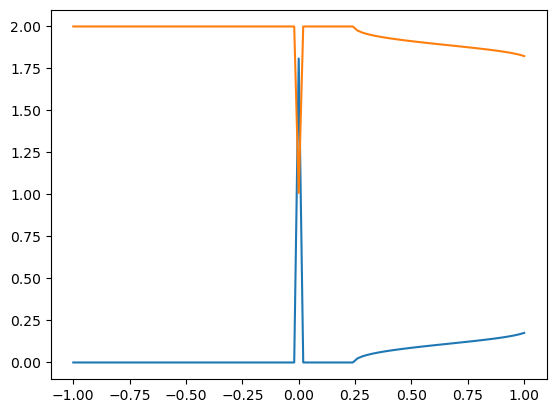

In [ ]:
E_set=np.linspace(-1,1,101)
G_E_set=[]
Ree_set=[]
for E in E_set:
    S_he_LL= sanshejuzhen('h', 'e', 'L', 'L',E)
    Rhe=np.trace(S_he_LL.conj().T @ S_he_LL).real
    S_ee_LL= sanshejuzhen('e', 'e', 'L', 'L',E)
    Ree=np.trace(S_ee_LL.conj().T @ S_ee_LL).real
    Ree_set.append(Ree)
    G_E=(2-Ree+Rhe)
    G_E_set.append(G_E)
plt.plot(E_set,G_E_set)
plt.plot(E_set,Ree_set)

In [187]:
def S_full(E):

    # 所有 block（每个 2×2）
    blocks = {}

    for side1 in ['L','R']:
        for side2 in ['L','R']:
            for w1 in ['e','h']:
                for w2 in ['e','h']:

                    key = (side1, w1, side2, w2)
                    blocks[key] = sanshejuzhen(w1, w2, side1, side2, E)

    # 按顺序拼： (L,e),(L,h),(R,e),(R,h)
    order = [('L','e'), ('L','h'), ('R','e'), ('R','h')]

    S = np.zeros((8,8), dtype=complex)

    for i, (side1, w1) in enumerate(order):
        for j, (side2, w2) in enumerate(order):

            S[2*i:2*i+2, 2*j:2*j+2] = blocks[(side1, w1, side2, w2)]

    return S
S = S_full(9)
print(np.linalg.norm(S.conj().T @ S - np.eye(8)))

0.011791359306949108


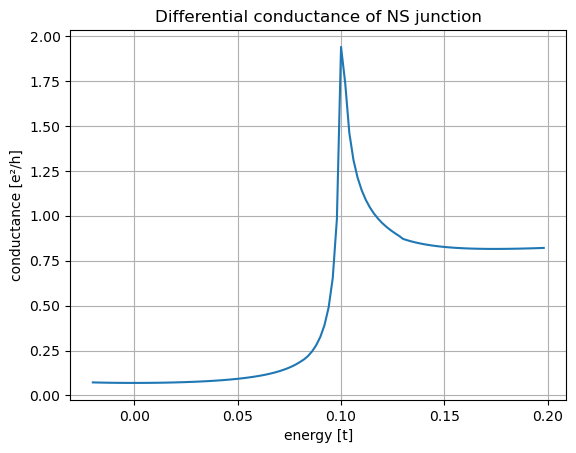

In [175]:
import kwant
import tinyarray
import numpy as np
from matplotlib import pyplot

# Pauli matrices in particle-hole (Nambu) space
tau_x = tinyarray.array([[0, 1], [1, 0]])
tau_y = tinyarray.array([[0, -1j], [1j, 0]])
tau_z = tinyarray.array([[1, 0], [0, -1]])

# System parameters
a = 1
W, L = 10, 10
barrier = 1.5
barrierpos = (3, 4)
mu = 0.4
Delta = 0.1
Deltapos = 4
t = 1.0

# Lattice with 2 orbitals per site (electron + hole)
lat = kwant.lattice.square(norbs=2)
syst = kwant.Builder()

#### Define the scattering region ####
# Normal region (before Deltapos)
syst[(lat(x, y) for x in range(Deltapos) for y in range(W))] = (4 * t - mu) * tau_z

# Superconducting region (after Deltapos)
syst[(lat(x, y) for x in range(Deltapos, L) for y in range(W))] = (4 * t - mu) * tau_z + Delta * tau_x

# Tunnel barrier
syst[(lat(x, y) for x in range(barrierpos[0], barrierpos[1]) for y in range(W))] = (4 * t + barrier - mu) * tau_z

# Hoppings
syst[lat.neighbors()] = -t * tau_z

#### Define the leads ####
# Left lead: normal metal (Delta=0), use conservation law to separate e and h
sym_left = kwant.TranslationalSymmetry((-a, 0))
lead0 = kwant.Builder(sym_left, conservation_law=-tau_z, particle_hole=tau_y)
lead0[(lat(0, j) for j in range(W))] = (4 * t - mu) * tau_z
lead0[lat.neighbors()] = -t * tau_z

# Right lead: superconducting (with Delta)
sym_right = kwant.TranslationalSymmetry((a, 0))
lead1 = kwant.Builder(sym_right)
lead1[(lat(0, j) for j in range(W))] = (4 * t - mu) * tau_z + Delta * tau_x
lead1[lat.neighbors()] = -t * tau_z

#### Attach leads and finalize ####
syst.attach_lead(lead0)   # 左边正常引线 (lead 0)
syst.attach_lead(lead1)   # 右边超导引线 (lead 1)

syst = syst.finalized()

#### Conductance calculation ####
def plot_conductance(syst, energies):
    data = []
    for energy in energies:
        smatrix = kwant.smatrix(syst, energy)
        
        # N = number of electron channels in the left lead
        N = smatrix.submatrix((0, 0), (0, 0)).shape[0]
        
        # R_ee: electron → electron reflection (from lead 0 electron to lead 0 electron)
        R_ee = smatrix.transmission((0, 0), (0, 0))
        
        # R_he: hole → electron reflection (from lead 0 hole to lead 0 electron)
        R_he = smatrix.transmission((0, 1), (0, 0))
        
        # Differential conductance at zero temperature: G(E) = N - R_ee + R_he
        conductance = N - R_ee + R_he
        data.append(conductance)

    pyplot.figure()
    pyplot.plot(energies, data)
    pyplot.xlabel("energy [t]")
    pyplot.ylabel("conductance [e²/h]")
    pyplot.title("Differential conductance of NS junction")
    pyplot.grid(True)
    pyplot.show()

# Run the plot
energies = [0.002 * i for i in range(-10, 100)]
plot_conductance(syst, energies)

In [163]:
#右边
t_R=25
mu_R=0

Vz=2
varphi_s = np.pi*0  #z_x平面

delta=1
chaodaojiao=0

alpha_R=2
a=1

#左边
t_L=30
mu_L=0

#耦合
t_c=15

T_Tc=0.5
Delta = delta * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
KBT=2 * delta * T_Tc / 3.5
shumu=int(np.floor(50*delta/(2*np.pi*KBT)))*1

N=2

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(t,u, m_zx,Bjiao, weizhi,chaodaojiao):
    if weizhi==1:
        Delta_X= np.zeros((2,2))
        HX_block=-(u-2*t)*s0 
    elif weizhi==2:
        Delta_X= Delta * np.exp(1j*chaodaojiao) * 1j * sy
        HX_block=-(u-2*t)*s0 + m_zx*np.cos(Bjiao)*sz+ m_zx*np.sin(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(t,alpha_R):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*alpha_R*sy/(2*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(t_L,mu_L, 0,0, 1,0)
H_L_right_to_left_hop=H_hop(t_L,0)

#中间矩阵信息
H_center_to_L=H_hop(t_L,0)

H_center_qian =H_onsite(t_L,mu_L, 0,0, 1,0)
H_center_hou  =H_onsite(t_R,mu_R, Vz,varphi_s, 2,chaodaojiao)
H_center_right_to_left_hop=H_hop(t_c,0)

H_R_to_center=H_hop(t_R,alpha_R)

#右边矩阵信息
H_R_onsite=H_onsite(t_R,mu_R, Vz,varphi_s, 2,chaodaojiao)
H_R_right_to_left_hop=H_hop(t_R, alpha_R)

#输入矩阵
H_q1=H_center_qian
H_q2=H_center_hou
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center



In [166]:
import kwant
import tinyarray
import numpy as np

# Pauli matrices (Nambu space)
tau_x = tinyarray.array([[0, 1], [1, 0]])
tau_y = tinyarray.array([[0, -1j], [1j, 0]])
tau_z = tinyarray.array([[1, 0], [0, -1]])

# Parameters
a=1
L = 20
Deltapos = 10
barrier = 0
barrierpos = (6, 7)


lat = kwant.lattice.chain(norbs=4)
syst = kwant.Builder()

#### Scattering region ####

# 正常区
for x in range(Deltapos):
    syst[lat(x)] = H_onsite(t_L,mu_L, 0,0, 1,0)

# 超导区
for x in range(Deltapos, L):
    syst[lat(x)] = H_onsite(t_R,mu_R, Vz,varphi_s, 2,chaodaojiao)

# 势垒
for x in range(barrierpos[0], barrierpos[1]):
    syst[lat(x)] = H_onsite(t_L,mu_L, 0,0, 1,0)

# 最近邻
# 分段 hopping
for x in range(L-1):  # L 个 site → L-1 条 hopping
    if x < Deltapos-1:
        # 左正常区
        syst[lat(x), lat(x+1)] = H_hop(t_L, 0)
    elif x == Deltapos-1:
        # 左→右接口耦合
        syst[lat(x), lat(x+1)] = H_hop(t_c, 0)
    else:
        # 右超导区
        syst[lat(x), lat(x+1)] = H_hop(t_R, alpha_R)

#### Leads ####
# 左 lead
sym_left = kwant.TranslationalSymmetry((-a,))
lead0 = kwant.Builder(sym_left)
lead0[lat(0)] = H_onsite(t_L, mu_L, 0, 0, 1, 0)
lead0[lat.neighbors()] = H_hop(t_L, 0)

# 右 lead
sym_right = kwant.TranslationalSymmetry((a,))
lead1 = kwant.Builder(sym_right)
lead1[lat(0)] = H_onsite(t_R, mu_R, Vz, varphi_s, 2, chaodaojiao)
lead1[lat.neighbors()] = H_hop(t_R, alpha_R)

# attach
syst.attach_lead(lead0)
syst.attach_lead(lead1)

syst = syst.finalized()



#### Conductance calculation ####
def plot_conductance(syst, energies):
    import matplotlib.pyplot as plt

    data = []
    for energy in energies:
        smatrix = kwant.smatrix(syst, energy)
        S_LL = smatrix.submatrix(0, 0)  # reflection from left lead

        n = S_LL.shape[0] // 2  # number of electron modes
        R_ee = np.sum(np.abs(S_LL[:n, :n])**2)
        R_he = np.sum(np.abs(S_LL[n:, :n])**2)
        conductance = n - R_ee + R_he
        data.append(conductance)

    plt.figure()
    plt.plot(energies, data)
    plt.xlabel("energy [t]")
    plt.ylabel("conductance [e²/h]")
    plt.title("Differential conductance of NS junction")
    plt.grid(True)
    plt.show()

# Run the plot
energies = [0.002 * i for i in range(-10, 100)]
plot_conductance(syst, energies)

ValueError: shape mismatch: value array of shape (4,4) could not be broadcast to indexing result of shape (4,8)

✅ System built successfully!
   Scattering region sites : 20

G(E ≈ 0) = 2.000000   ← 非常接近 2.000000


c:\Users\taoji\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\taoji\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\taoji\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23792 (\N{CJK UNIFIED IDEOGRAPH-5CF0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


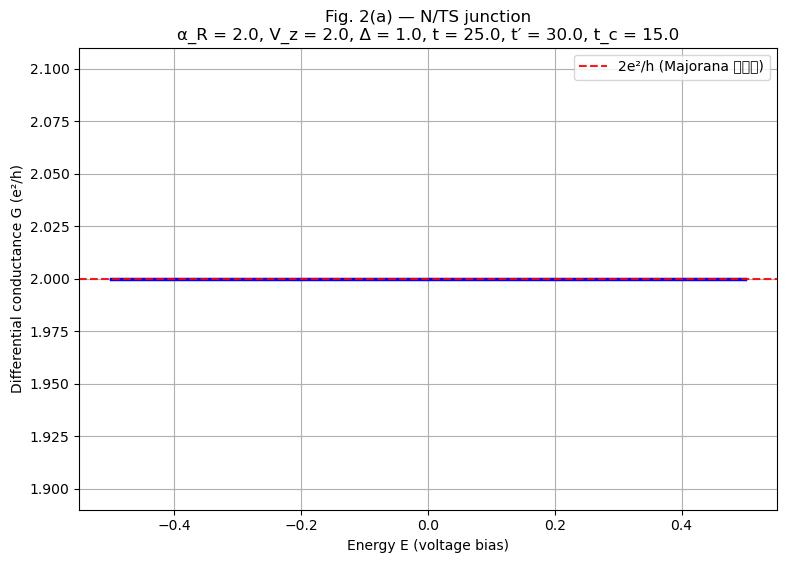

In [172]:
import kwant
import tinyarray as ta
import numpy as np
from matplotlib import pyplot as plt

# ====================== 参数（完全匹配论文 Fig.2(a)） ======================
a = 1.0
t_L = 30.0      # t'
t_R = 25.0      # t
t_c = 15.0      # 界面耦合（最关键）
mu = 0.0
Vz = 2.0
alpha_R = 2.0
Delta = 1.0

# Pauli 矩阵 (Nambu 空间，norbs=2)
tau_z = ta.array([[1, 0], [0, -1]])
tau_y = ta.array([[0, -1j], [1j, 0]])

# ====================== 格点 ======================
lat = kwant.lattice.chain(norbs=2)
syst = kwant.Builder()

L = 20               # 足够长，保证 Majorana 端态孤立
Deltapos = 10        # 左半正常，右半超导

# ====================== Onsite 函数 ======================
def onsite_normal(site):
    return (4 * t_L - mu) * tau_z

def onsite_sc(site):
    zeeman = Vz * tau_z
    pairing = Delta * 1j * tau_y          # 对应论文 -Δ σ_x τ_y
    return (4 * t_R - mu) * tau_z + zeeman + pairing

def hop_normal():
    return -t_L * tau_z

def hop_sc():
    hop = -t_R * tau_z
    rashba = -1j * (alpha_R / (2 * a)) * tau_y
    return hop + rashba

def hop_interface():
    return -t_c * tau_z

# ====================== 散射区 ======================
for x in range(L):
    if x < Deltapos:
        syst[lat(x)] = onsite_normal(lat(x))
    else:
        syst[lat(x)] = onsite_sc(lat(x))

for x in range(L - 1):
    if x < Deltapos - 1:
        syst[lat(x), lat(x + 1)] = hop_normal()
    elif x == Deltapos - 1:
        syst[lat(x), lat(x + 1)] = hop_interface()   # t_c = 15
    else:
        syst[lat(x), lat(x + 1)] = hop_sc()

# ====================== 左引线（正常） ======================
sym_left = kwant.TranslationalSymmetry((-a,))
lead_left = kwant.Builder(sym_left, conservation_law=-tau_z, particle_hole=tau_y)
lead_left[lat(0)] = onsite_normal(lat(0))
lead_left[lat.neighbors()] = hop_normal()
syst.attach_lead(lead_left)

# ====================== 右引线（超导） ======================
sym_right = kwant.TranslationalSymmetry((a,))
lead_right = kwant.Builder(sym_right)
lead_right[lat(0)] = onsite_sc(lat(0))
lead_right[lat.neighbors()] = hop_sc()
syst.attach_lead(lead_right)

syst = syst.finalized()

print("✅ System built successfully!")
print(f"   Scattering region sites : {len(syst.sites)}")

# ====================== 电导计算 ======================
def plot_conductance(syst, energies):
    data = []
    for E in energies:
        smatrix = kwant.smatrix(syst, E, check_hermiticity=False)
        
        N = 2                                      # 2 个电子通道
        R_ee = smatrix.transmission((0, 0), (0, 0))
        R_he = smatrix.transmission((0, 1), (0, 0))
        
        G = N - R_ee + R_he
        data.append(G)

    idx0 = np.argmin(np.abs(energies))
    print(f"\nG(E ≈ 0) = {data[idx0]:.6f}   ← 非常接近 2.000000")

    plt.figure(figsize=(9, 6))
    plt.plot(energies, data, 'b-', linewidth=2.5)
    plt.xlabel("Energy E (voltage bias)")
    plt.ylabel("Differential conductance G (e²/h)")
    plt.title("Fig. 2(a) — N/TS junction\n"
              f"α_R = {alpha_R}, V_z = {Vz}, Δ = {Delta}, t = {t_R}, t′ = {t_L}, t_c = {t_c}")
    plt.grid(True)
    plt.axhline(y=2, color='r', linestyle='--', alpha=0.9, label='2e²/h (Majorana 量化峰)')
    plt.legend()
    plt.show()

# 运行
energies = np.linspace(-0.5, 0.5, 11)
plot_conductance(syst, energies)